In [1]:
%load_ext autoreload
%autoreload 2
%env CUPY_ACCELERATORS=cutensor,cub

env: CUPY_ACCELERATORS=cutensor,cub


In [2]:
import tensorly as tl
import plotly.io as pio
#pio.renderers.default = 'iframe'
tl.set_backend('numpy')
tl.tenalg.set_backend('einsum')
tl.plugins.use_opt_einsum()
print(f'TensorLy backend: {tl.get_backend()}')

TensorLy backend: numpy


In [3]:
from moabb.datasets import *
from moabb.paradigms import P300

dataset = BNCI2014_008()
paradigm = P300(tmin=0.2)
X, y, meta = paradigm.get_data(dataset)
X = tl.tensor(X)
X.shape

/data/leuven/352/vsc35289/miniconda3/envs/bttda-cuda/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:278: UserWarning: warnEpochs <Epochs | 4200 events (all good), 0.199 – 1 s (baseline off), ~52.8 MiB, data loaded,
 'Target': 700
 'NonTarget': 3500>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda-cuda/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:278: UserWarning: warnEpochs <Epochs | 4200 events (all good), 0.199 – 1 s (baseline off), ~52.8 MiB, data loaded,
 'Target': 700
 'NonTarget': 3500>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda-cuda/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:278: UserWarning: warnEpochs <Epochs | 4200 events (all good), 0.199 – 1 s (baseline off), ~52.8 MiB, data loaded,
 'Target': 700
 'NonTarget': 3500>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda-cuda/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:2

(33600, 8, 206)

In [4]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import PCA
from hoda.classification import SelectFCutoff
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

clf = make_pipeline(
    FunctionTransformer(tl.to_numpy),
    PCA(n_components=None, whiten=True),
    SelectFCutoff(cutoff=1),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)

In [5]:
hoda_params=  dict(
    max_iter=64,
    toeplitz=(1,),
    taper=False,
    verbose=False,
    refit_shrinkage=True,
)

In [6]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5)

bttdacv_params = dict(
    hoda_params=hoda_params,
    verbose=False,
    cv=cv,
    clf = clf,
)

In [7]:
from hoda.classification import BTTDACV

"""
bttdacv = BTTDACV(
    max_n_blocks=1,
    fixed_n_blocks=True,
    thetas=[0,0.1,0.2,0.3,0.4,0.5,0.6, 0.7, 0.8, 0.9,1],
    **bttdacv_params
)
"""
bttdacv =  BTTDACV(
    max_n_blocks=16,
    fixed_n_blocks=True,
    thetas=[0],
    **bttdacv_params
)

In [8]:
import joblib
from joblib import Parallel, delayed
from hpc import create_cluster, create_client, TIMEOUT


with create_cluster(cluster='batch_sapphirerapids') as cluster, create_client(cluster) as client:     
    with joblib.parallel_backend('dask', wait_for_workers_timeout=TIMEOUT): 
        bttdacv.fit(X,y)

/vsc-hard-mounts/leuven-data/352/vsc35289/hoda-bci/src/hoda/hoda.py:357: UserWarning: Maximum number of iterations reached without convergence
  warnings.warn("Maximum number of iterations reached without convergence")
Exception in callback multi_future.<locals>.callback(<Task cancell...ession.py:77>>) at /data/leuven/352/vsc35289/miniconda3/envs/bttda-cuda/lib/python3.11/site-packages/tornado/gen.py:540
handle: <Handle multi_future.<locals>.callback(<Task cancell...ession.py:77>>) at /data/leuven/352/vsc35289/miniconda3/envs/bttda-cuda/lib/python3.11/site-packages/tornado/gen.py:540>
Traceback (most recent call last):
  File "/data/leuven/352/vsc35289/miniconda3/envs/bttda-cuda/lib/python3.11/asyncio/events.py", line 84, in _run
    self._context.run(self._callback, *self._args)
  File "/data/leuven/352/vsc35289/miniconda3/envs/bttda-cuda/lib/python3.11/site-packages/tornado/gen.py", line 546, in callback
    result_list.append(f.result())
                       ^^^^^^^^^^
  File "/da

(206, 1)


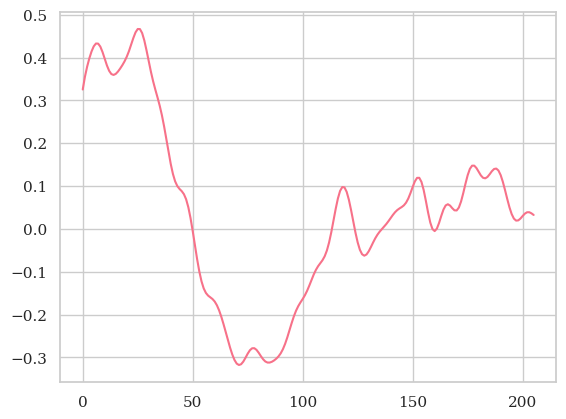

(206, 1)


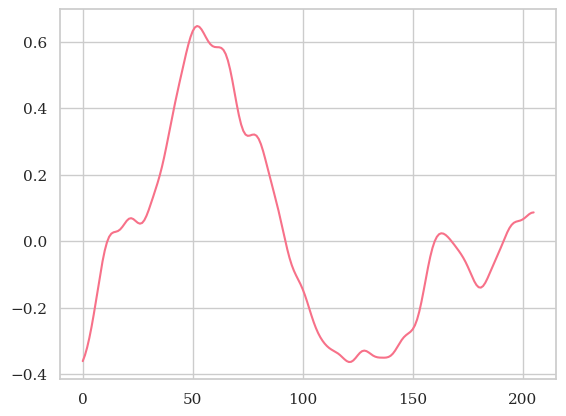

(206, 1)


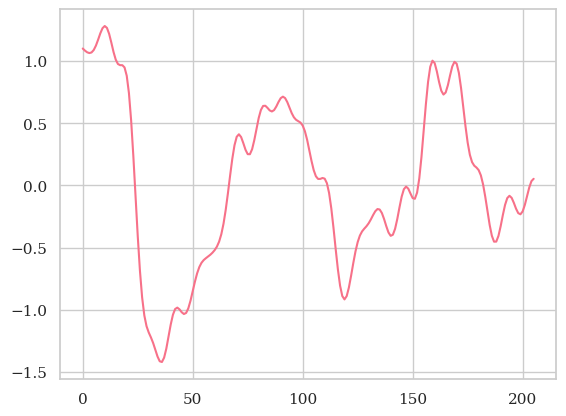

(206, 1)


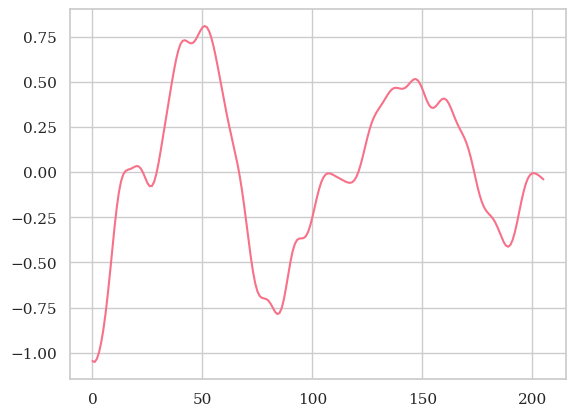

(206, 1)


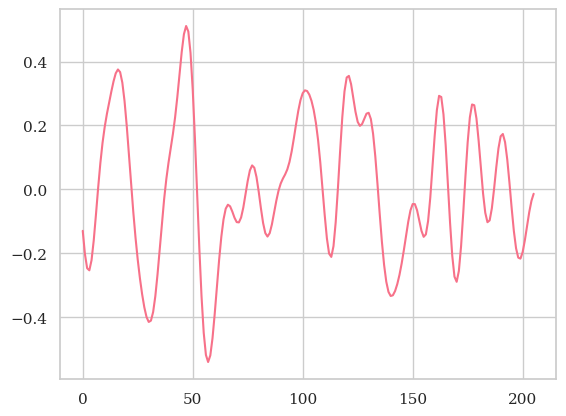

(206, 1)


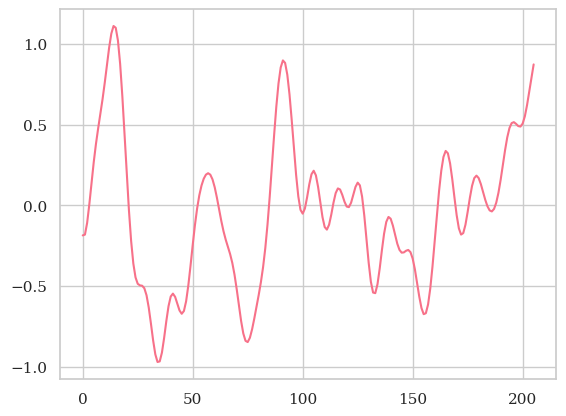

(206, 1)


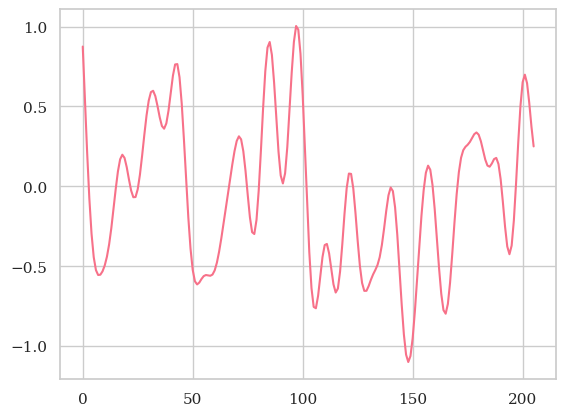

(206, 1)


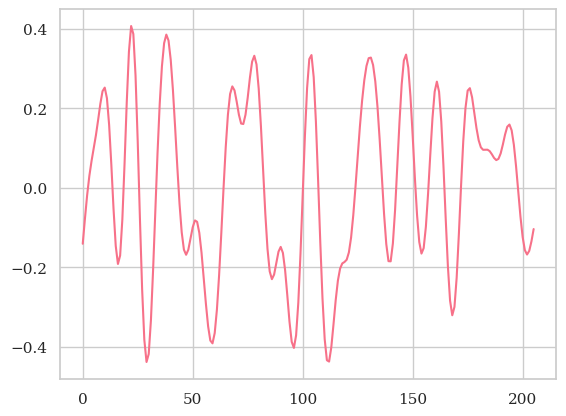

(206, 1)


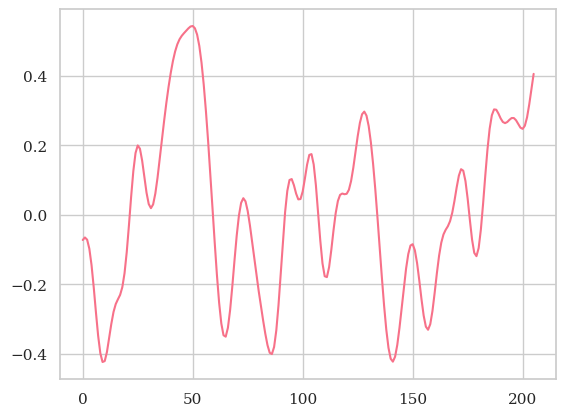

(206, 1)


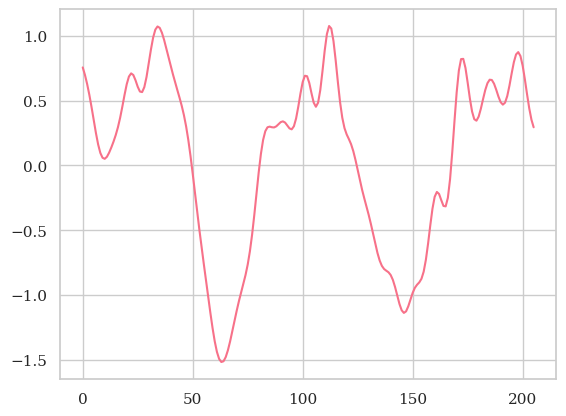

(206, 1)


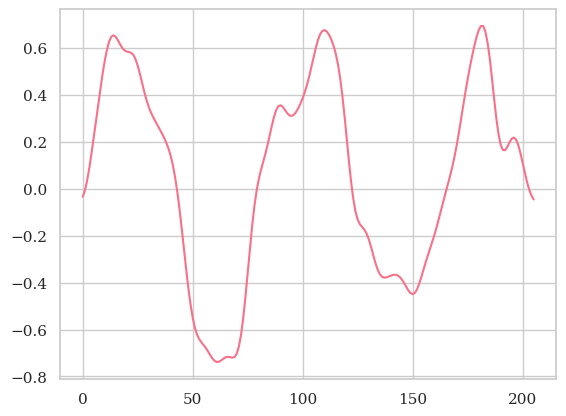

(206, 1)


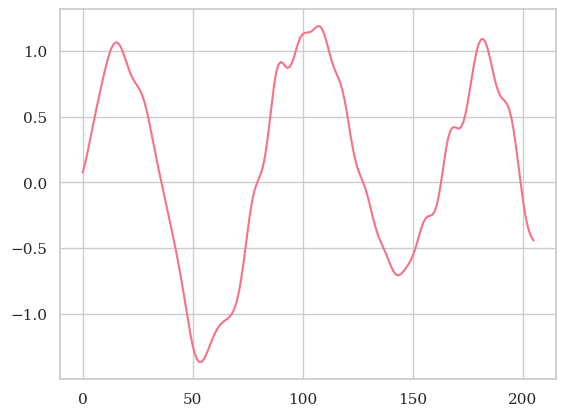

(206, 1)


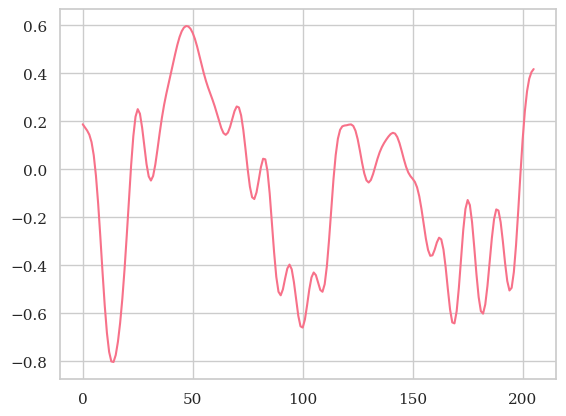

(206, 1)


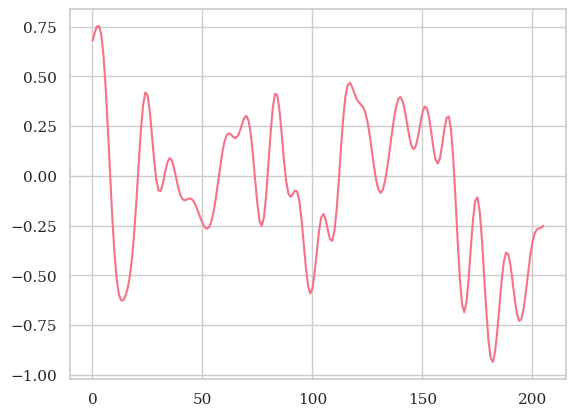

(206, 1)


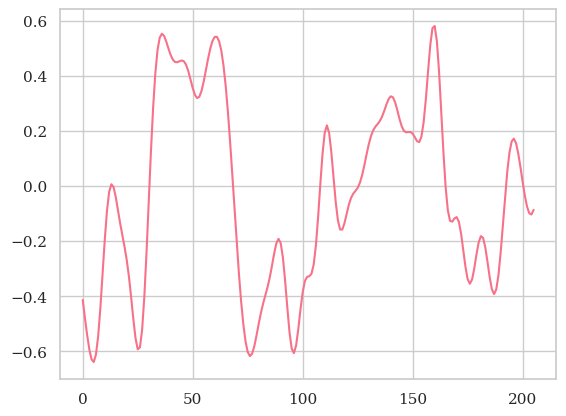

(206, 1)


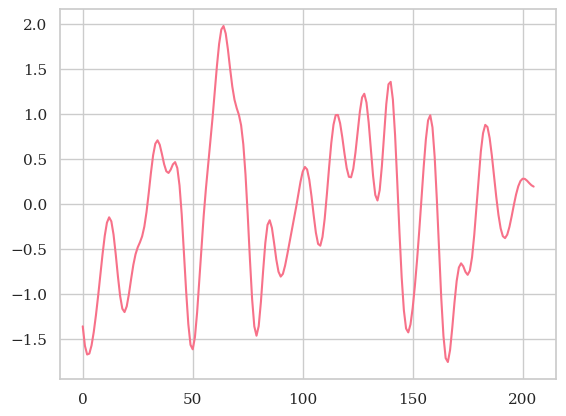

In [9]:
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

for b in bttdacv.blocks_:
    print(b.aps_[1].shape)
    plt.plot(b.aps_[1])
    plt.show()